# Gaussian beam through an MNIST mask

A Gaussian beam travels `source_distance` from its waist to an illuminated
mask showing a binary MNIST digit, and the transmitted field then propagates
`mask_distance` to the next layer.

In [45]:
import sys

sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import torch

from d2nn.data import mnist_digit
from d2nn.optics.beam import GaussianBeam
from d2nn.optics.propagation import Propagation

# Gaussian source
waist_radius = 0.0066  # m, beam waist
wavelength = 0.75e-3  # m
source_distance = 0.173  # m, distance to the illuminated mask layer
beam_quality = 5.33

# Mask
digit = 5
layer_size = 200  # px grid
pixel_size = 0.4e-3  # m
mask_size = 0.4  # digit spans this fraction of the layer

# Mask to the next layer
mask_distance = 0.03  # m

In [46]:
digit_size = round(layer_size * mask_size)
image = mnist_digit(digit, root="../data", size=digit_size, index=2)
mask = (image > 0.5).to(torch.float64)

padding = layer_size - digit_size
mask = torch.nn.functional.pad(mask, (padding // 2,) * 4)

In [47]:
beam = GaussianBeam(
    size=layer_size,
    pixel_size=pixel_size,
    wavelength=wavelength,
    distance=source_distance,
    waist_radius=waist_radius,
    beam_quality=beam_quality,
)

propagation = Propagation(
    size=layer_size,
    pixel_size=pixel_size,
    wavelength=wavelength,
    distance=mask_distance,
)

field = beam.field()  # Gaussian field at the mask layer
incident = field.abs() ** 2  # intensity before the mask
transmitted = beam(mask)  # field immediately after the mask
next_layer = propagation(transmitted)  # field at the next layer
next_layer_const_amplitude = propagation(
    mask
)  # field at the next layer with const amplitude mask

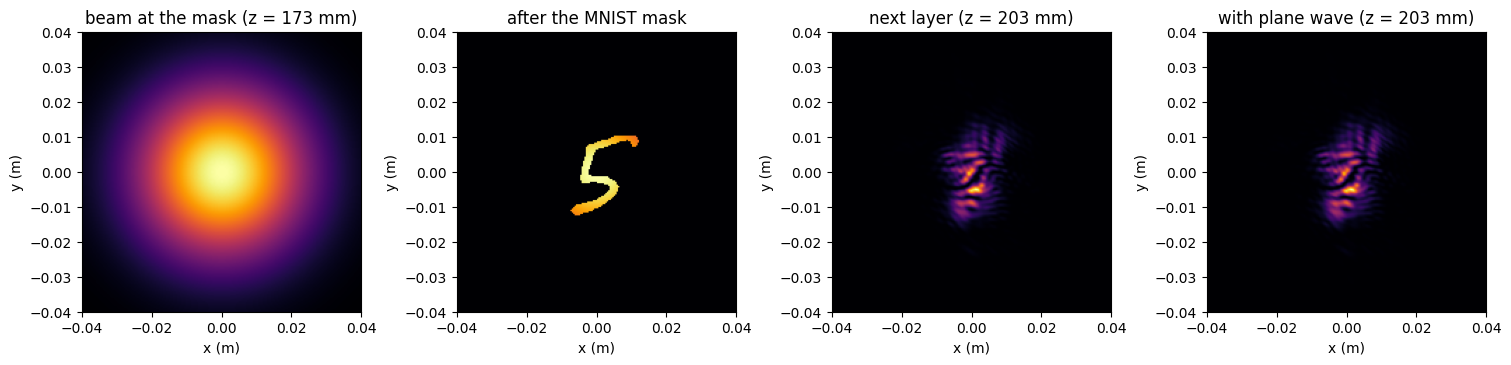

In [48]:
extent = [
    -layer_size * pixel_size / 2,
    layer_size * pixel_size / 2,
    -layer_size * pixel_size / 2,
    layer_size * pixel_size / 2,
]
images = {
    f"beam at the mask (z = {source_distance * 1e3:.0f} mm)": incident,
    "after the MNIST mask": transmitted.abs() ** 2,
    f"next layer (z = {(source_distance + mask_distance) * 1e3:.0f} mm)": next_layer.abs()
    ** 2,
    f"with plane wave (z = {(source_distance + mask_distance) * 1e3:.0f} mm)": next_layer_const_amplitude.abs()
    ** 2,
}

fig, axes = plt.subplots(1, 4, figsize=(15, 5), constrained_layout=True)
for ax, (title, intensity) in zip(axes, images.items(), strict=True):
    ax.set_title(title)
    ax.imshow(intensity.cpu().numpy(), extent=extent, cmap="inferno", origin="upper")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
_ = fig